<a href="https://colab.research.google.com/github/priyanka8637kumari/google-playstore-rating-prediction/blob/main/google_playstore_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Play Store - App Rating Prediction

## Motivation

The goal of this project is to predict whether a Google Play Store app
is highly rated (rating above 4.0) based on features like category,
number of reviews, size, installs, and price.

App ratings directly impact visibility and downloads on the Play Store —
understanding what makes an app highly rated is valuable for developers
and businesses building mobile products.

The Google Play Store dataset contains around 10,000 apps with real-world
messy data — including missing values, mixed formats, and categorical
columns — making it a realistic and practical dataset to work with.

**Task type:** Classification  
**Target variable:** High rating (1 = rated 4.0 or above, 0 = below 4.0)  
**Dataset source:** Kaggle - Google Play Store Apps

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier

# Load the dataset
df = pd.read_csv('googleplaystore.csv')

# Cheking first look of data
print(df.shape)
df.head()

(10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Step 2: Data Preparation

In [51]:
# Check missing values
print(df.isnull().sum())

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


### Handling Missing Values

The dataset has missing values in 5 columns:

- **Rating (1474 missing)** — this is our target column, so we cannot
  guess or fill these values. We drop all rows where Rating is missing.

- **Type, Content Rating, Current Ver, Android Ver** — these have very
  few missing values (1–8 rows). We fill them with the most common value
  (mode) since they are categorical columns.

After cleaning, we check again to confirm no missing values remain.

In [52]:
# Drop rows where Rating is missing (it's our target column, can't fill it)
df = df.dropna(subset=['Rating'])

# Fill minor missing values with mode (most common value)
df['Type'] = df['Type'].fillna(df['Type'].mode()[0])
df['Content Rating'] = df['Content Rating'].fillna(df['Content Rating'].mode()[0])
df['Current Ver'] = df['Current Ver'].fillna(df['Current Ver'].mode()[0])
df['Android Ver'] = df['Android Ver'].fillna(df['Android Ver'].mode()[0])

# Verify no missing values remain
print(df.isnull().sum())
print("\nRows remaining:", len(df))

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

Rows remaining: 9367


### Creating Target Variable

In [53]:
# Create target column: 1 if rating >= 4.0, else 0
df['HighRating'] = (df['Rating'] >= 4.0).astype(int)

# Check the balance
print(df['HighRating'].value_counts())
print("\nPercentage:")
print(df['HighRating'].value_counts(normalize=True).round(2) * 100)

HighRating
1    7369
0    1998
Name: count, dtype: int64

Percentage:
HighRating
1    79.0
0    21.0
Name: proportion, dtype: float64


### Target Variable Distribution

79% of apps have a high rating (4.0 or above) and 21% do not.
This is an imbalanced dataset — the model will see far more highly
rated apps during training, which may affect its ability to correctly
predict low rated apps. This is a limitation worth noting.

### Data Visualization

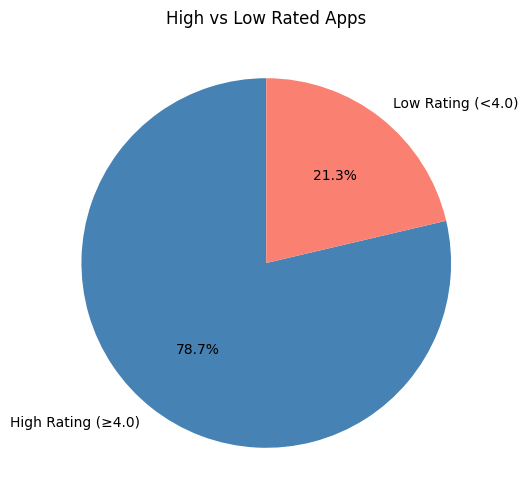

In [54]:
# Pie chart - High vs Low rating
labels = ['High Rating (≥4.0)', 'Low Rating (<4.0)']
sizes = df['HighRating'].value_counts()
colors = ['steelblue', 'salmon']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('High vs Low Rated Apps')
plt.show()

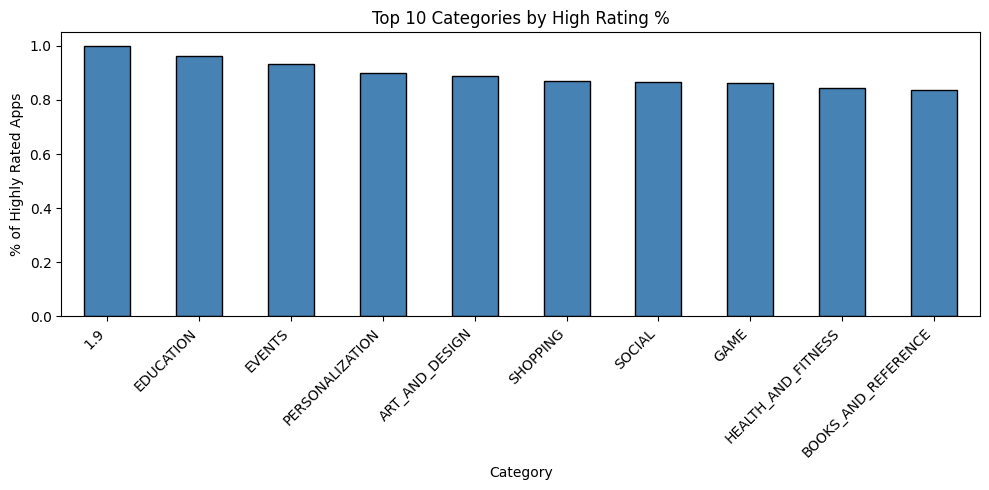

In [55]:
# Bar chart - average rating by category
category_ratings = df.groupby('Category')['HighRating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
category_ratings.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Categories by High Rating %')
plt.xlabel('Category')
plt.ylabel('% of Highly Rated Apps')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observation - Chart 2

The bar chart reveals an interesting data quality issue — a value "1.9"
appears as a category name, which is clearly a dirty row in the dataset
where a rating value ended up in the wrong column. This is a good example
of why real-world data always needs careful cleaning before training a model.

Among valid categories, Education, Events, and Personalization have the
highest percentage of highly rated apps.

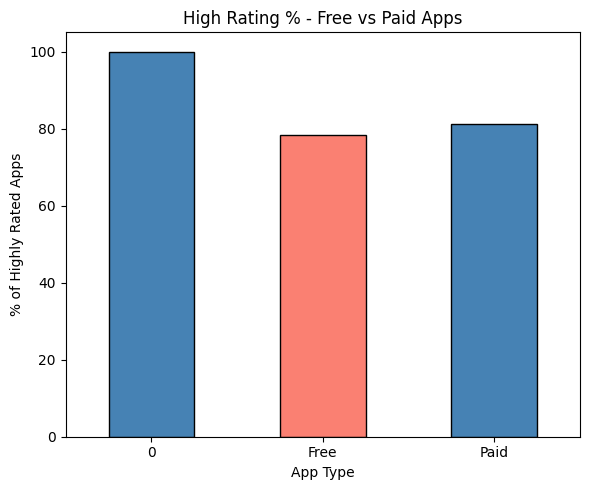

In [56]:
# Bar chart - Free vs Paid apps high rating %
type_ratings = df.groupby('Type')['HighRating'].mean() * 100

plt.figure(figsize=(6, 5))
type_ratings.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('High Rating % - Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('% of Highly Rated Apps')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation - Chart 3

The chart shows another data quality issue — "0" appears as an app type,
which is a dirty row that needs to be removed during cleaning.

Ignoring that, the difference between Free and Paid apps is very small
(~79% vs ~81% highly rated). This suggests that whether an app is free
or paid has very little impact on its rating — users rate based on
quality, not price.

### Chart 4: Reviews vs Rating (Seaborn)

This scatter plot shows the relationship between number of reviews
and app rating. Each dot is colored by whether the app is highly
rated or not — blue for high rating, orange for low rating.

More reviews generally means more users, which can indicate
a more established and trusted app.

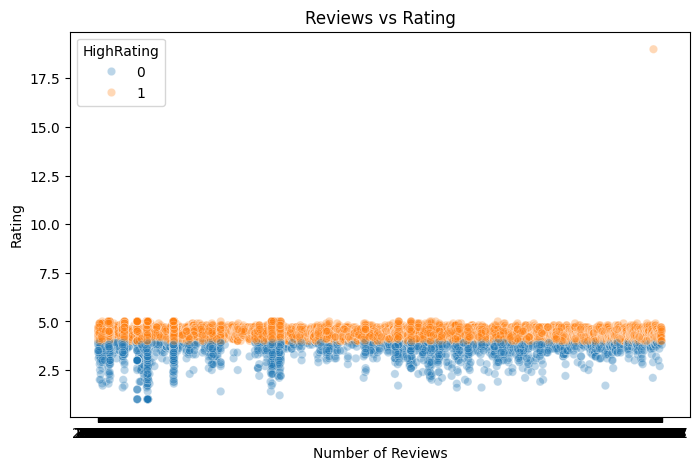

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='Reviews', y='Rating',
                hue='HighRating', alpha=0.3, ax=ax)
ax.set_title('Reviews vs Rating')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Rating')
plt.show()
plt.close(fig)

### Cleaning Messy Columns

Several columns have messy formats that need to be fixed before
the model can use them:

- **Size** — values like "19M" and "8.7k" need to be converted
  to plain numbers. Rows with "Varies with device" are replaced
  with the median size.

- **Installs** — values like "10,000+" need the "+" and ","
  removed so they can be read as numbers.

- **Price** — values like "$4.99" need the "$" removed and
  converted to a number.

- **Category and Type** — dirty rows with values "1.9" and "0"
  are removed as they are clearly data entry errors spotted
  during visualization.

In [58]:
# Clean Size column - convert to numeric (MB)
df['Size'] = df['Size'].replace('Varies with device', np.nan)
df['Size'] = df['Size'].str.replace('M', '').str.replace('k', 'e-3')
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
df['Size'] = df['Size'].fillna(df['Size'].median())

# Clean Installs column - remove + and , and convert to numeric
df['Installs'] = df['Installs'].str.replace('+', '').str.replace(',', '')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean Price column - remove $ and convert to numeric
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Remove dirty rows in Category and Type
df = df[df['Category'] != '1.9']
df = df[df['Type'] != '0']

# Verify
print(df[['Size', 'Installs', 'Price']].head())
print("\nRows remaining:", len(df))

   Size    Installs  Price
0  19.0     10000.0    0.0
1  14.0    500000.0    0.0
2   8.7   5000000.0    0.0
3  25.0  50000000.0    0.0
4   2.8    100000.0    0.0

Rows remaining: 9366


### Converting Categorical Columns to Numeric

Machine learning models can only work with numbers, not text.
We convert categorical columns like Category, Type, and Content
Rating into numeric representations using Label Encoding — each
unique text value gets assigned a number.

In [59]:
le = LabelEncoder()

# Convert categorical columns to numeric
df['Category'] = le.fit_transform(df['Category'])
df['Type'] = le.fit_transform(df['Type'])
df['Content Rating'] = le.fit_transform(df['Content Rating'])

# Verify
print(df[['Category', 'Type', 'Content Rating']].head())

   Category  Type  Content Rating
0         0     0               1
1         0     0               1
2         0     0               1
3         0     0               4
4         0     0               1


### Selecting Features

We select the columns most relevant to predicting app ratings.
Columns like App name, Last Updated, Current Ver, and Genres
are dropped because they don't have meaningful predictive value
for our model.

In [60]:
# Select features to use
features = ['Category', 'Reviews', 'Size',
            'Installs', 'Type', 'Price', 'Content Rating']

X = df[features]
y = df['HighRating']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:", list(X.columns))

Features shape: (9366, 7)
Target shape: (9366,)

Features used: ['Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating']


### Splitting Data into Train and Test Sets

We split the data 80% for training and 20% for testing.
The model will only learn from the training set and will
be evaluated on the test set — data it has never seen before.

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (7492, 7)
Test size: (1874, 7)


### Training the Model

We use Logistic Regression — a simple and interpretable model
well suited for binary classification problems. It predicts
the probability of an app being highly rated (1) or not (0).

In [62]:
# Create and train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


### Evaluating the Model

We test the model on the 1874 rows it has never seen before.
We use the following metrics:

- **Accuracy** — overall percentage of correct predictions
- **Precision** — of all apps predicted highly rated, how many actually were?
- **Recall** — of all actually highly rated apps, how many did we catch?
- **F1 Score** — balance between precision and recall

In [63]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("Precision:", round(precision_score(y_test, y_pred), 2))
print("Recall:", round(recall_score(y_test, y_pred), 2))
print("F1 Score:", round(f1_score(y_test, y_pred), 2))

print("\nFull Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.79
Precision: 0.79
Recall: 1.0
F1 Score: 0.88

Full Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       395
           1       0.79      1.00      0.88      1479

    accuracy                           0.79      1874
   macro avg       0.39      0.50      0.44      1874
weighted avg       0.62      0.79      0.70      1874



### Model Performance Analysis

The model achieved 79% accuracy but this is misleading.
Looking at the full report, the model predicted every app
as highly rated (class 1) and completely failed to identify
low rated apps (class 0) — giving 0.00 precision and recall for that class.

This is caused by the imbalanced dataset — 79% of apps are highly
rated, so the model learned to always predict "high rating" as a
safe default.

This is an important limitation and a good example of why accuracy
alone is not enough to evaluate a classification model.

In [64]:
# Retrain with class_weight='balanced' to handle imbalanced data
model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

# Evaluate
y_pred_balanced = model_balanced.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_balanced), 2))
print("Precision:", round(precision_score(y_test, y_pred_balanced), 2))
print("Recall:", round(recall_score(y_test, y_pred_balanced), 2))
print("F1 Score:", round(f1_score(y_test, y_pred_balanced), 2))

print("\nFull Report:")
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.48
Precision: 0.94
Recall: 0.37
F1 Score: 0.53

Full Report:
              precision    recall  f1-score   support

           0       0.28      0.91      0.42       395
           1       0.94      0.37      0.53      1479

    accuracy                           0.48      1874
   macro avg       0.61      0.64      0.48      1874
weighted avg       0.80      0.48      0.51      1874



### Comparing Both Models

| Metric    | Original Model | Balanced Model |
|-----------|---------------|----------------|
| Accuracy  | 0.79          | 0.48           |
| Precision | 0.79          | 0.94           |
| Recall    | 1.00          | 0.37           |
| F1 Score  | 0.88          | 0.53           |

The original model predicted everything as highly rated.
The balanced model overcorrected and now misses too many
highly rated apps.

This shows that the imbalanced dataset is the core challenge
with this data. A possible improvement would be to use a
Random Forest model or apply SMOTE (oversampling technique)
to better handle the class imbalance.

### Trying Random Forest Model

We test Random Forest as an alternative to Logistic Regression.
Random Forest builds multiple decision trees and combines their
predictions — it often handles imbalanced datasets better than
Logistic Regression.

In [65]:
# Create and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 2))
print("Precision:", round(precision_score(y_test, y_pred_rf), 2))
print("Recall:", round(recall_score(y_test, y_pred_rf), 2))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 2))

print("\nFull Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8
Precision: 0.83
Recall: 0.94
F1 Score: 0.88

Full Report:
              precision    recall  f1-score   support

           0       0.54      0.27      0.36       395
           1       0.83      0.94      0.88      1479

    accuracy                           0.80      1874
   macro avg       0.68      0.60      0.62      1874
weighted avg       0.77      0.80      0.77      1874



### Random Forest Results

Random Forest outperformed both Logistic Regression models overall.
It achieved 80% accuracy with a good balance between precision (0.83)
and recall (0.94) for highly rated apps.

It still struggles with low rated apps (class 0 recall: 0.27) due to
the imbalanced dataset, but performs significantly better than the
original Logistic Regression which completely failed on class 0.

Random Forest is the best performing model in this project.